In [24]:
import os
from pathlib import Path

import clickhouse_connect
import matplotlib.pyplot as plt
import polars as pl
from dotenv import load_dotenv

ENV_PATH = Path.cwd().parent / ".env"

load_dotenv(ENV_PATH)

clickhouse_host = "localhost"
clickhouse_port = int(os.getenv("CLICKHOUSE_PORT", "8123"))
clickhouse_user = os.getenv("CLICKHOUSE_USER", "minimarket_user")
clickhouse_password = os.getenv("CLICKHOUSE_PASSWORD", "minimarket_password")
clickhouse_db = os.getenv("CLICKHOUSE_DB", "minimarket")
print(f"Connecting to ClickHouse at {clickhouse_host}:{clickhouse_port} with user {clickhouse_user} and database {clickhouse_db}")


Connecting to ClickHouse at localhost:8123 with user clickhouse and database minimarket


In [25]:
client = clickhouse_connect.get_client(
    host=clickhouse_host,
    port=clickhouse_port,
    username=clickhouse_user,
    password=clickhouse_password,
    database=clickhouse_db,
)


def query_to_polars(sql: str) -> pl.DataFrame:
    result = client.query(sql)

    return pl.DataFrame(
        result.result_rows,
        schema=result.column_names,
        orient="row",
    )

In [26]:
tables = query_to_polars("""
    show tables
""")

tables

name
str
"""dim_customer"""
"""dim_date"""
"""dim_product"""
"""fact_sales"""
"""raw_customers"""
…
"""raw_transactions"""
"""stg_customers"""
"""stg_products"""


In [27]:
fact_count = query_to_polars("""
    select count(*) as row_count
    from fact_sales
""")

fact_count

row_count
i64
2382


In [28]:
top_products = query_to_polars("""
    with product_sales as (
        select
            dp.category,
            dp.product_name,
            sum(fs.quantity) as total_quantity
        from fact_sales fs
        inner join dim_product dp
            on fs.product_key = dp.product_key
        group by
            dp.category,
            dp.product_name
    ),

    ranked as (
        select
            category,
            product_name,
            total_quantity,
            row_number() over (
                partition by category
                order by total_quantity desc
            ) as product_rank
        from product_sales
    )

    select
        category,
        product_name,
        total_quantity
    from ranked
    where product_rank <= 5
    order by
        category,
        total_quantity desc
""")

top_products

category,product_name,total_quantity
str,str,i64
"""Beverage""","""Aqua 600ml Variant 41""",100
"""Beverage""","""Aqua 600ml Variant 31""",98
"""Beverage""","""Aqua 600ml Variant 1""",98
"""Beverage""","""Aqua 600ml Variant 21""",96
"""Beverage""","""Aqua 600ml Variant 11""",96
…,…,…
"""Snack""","""Pepsodent 75g Variant 47""",177
"""Snack""","""Pepsodent 75g Variant 37""",177
"""Snack""","""Pepsodent 75g Variant 27""",174


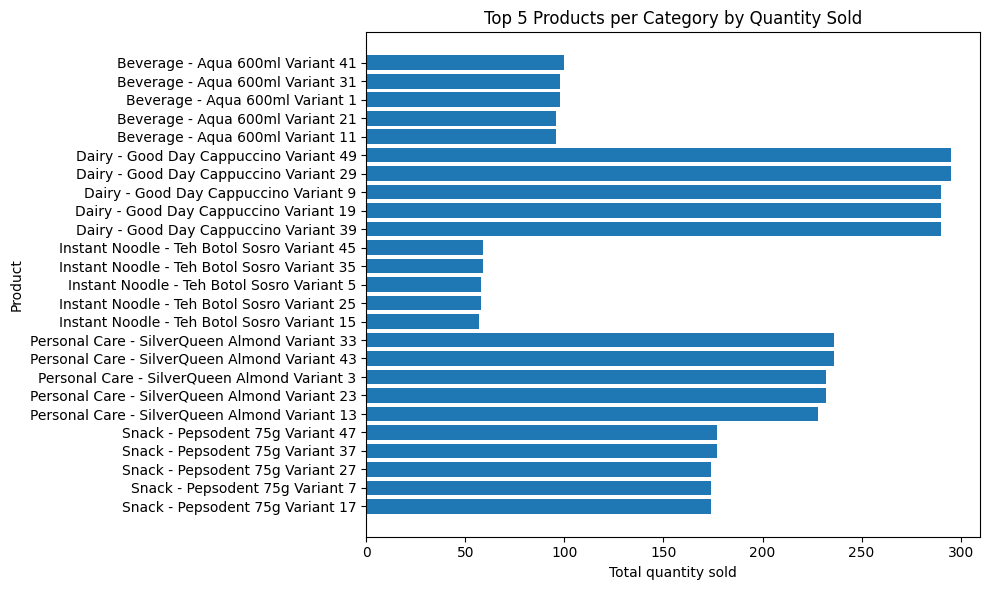

In [29]:
top_products_plot = top_products.with_columns(
    (
        pl.col("category") + " - " + pl.col("product_name")
    ).alias("label")
)

labels = top_products_plot["label"].to_list()
values = top_products_plot["total_quantity"].to_list()

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Total quantity sold")
plt.ylabel("Product")
plt.title("Top 5 Products per Category by Quantity Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
monthly_revenue = query_to_polars("""
    select
        dd.year,
        dd.month,
        dd.month_name,
        sum(fs.subtotal) as total_revenue
    from fact_sales fs
    inner join dim_date dd
        on fs.date_key = dd.date_key
    group by
        dd.year,
        dd.month,
        dd.month_name
    order by
        dd.year,
        dd.month
""")

monthly_revenue

year,month,month_name,total_revenue
i64,i64,str,"decimal[*,2]"
2026,1,"""January""",15968638.25
2026,2,"""February""",15384953.25
2026,3,"""March""",16249734.25
2026,4,"""April""",14889166.25
2026,5,"""May""",13258282.75
2026,6,"""June""",13273648.25


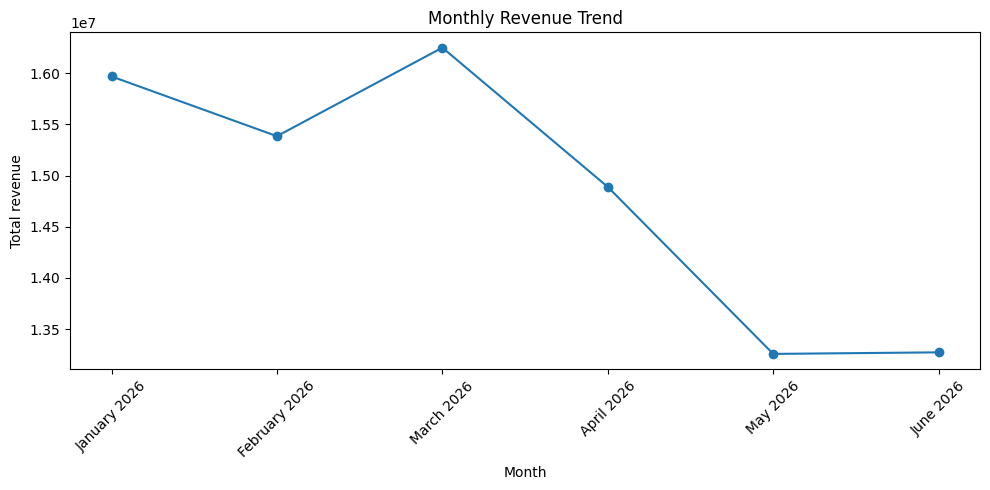

In [31]:
monthly_revenue_plot = monthly_revenue.with_columns(
    (
        pl.col("month_name") + " " + pl.col("year").cast(pl.Utf8)
    ).alias("month_label")
)

x_labels = monthly_revenue_plot["month_label"].to_list()
revenues = monthly_revenue_plot["total_revenue"].to_list()

plt.figure(figsize=(10, 5))
plt.plot(x_labels, revenues, marker="o")
plt.xlabel("Month")
plt.ylabel("Total revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
payment_distribution = query_to_polars("""
    select
        payment_method,
        count(distinct transaction_id) as transaction_count,
        round(
            count(distinct transaction_id) * 100.0
            / sum(count(distinct transaction_id)) over (),
            2
        ) as percentage
    from fact_sales
    group by payment_method
    order by transaction_count desc
""")

payment_distribution

payment_method,transaction_count,percentage
str,i64,f64
"""e-wallet""",243,26.3
"""credit""",243,26.3
"""debit""",243,26.3
"""cash""",195,21.1


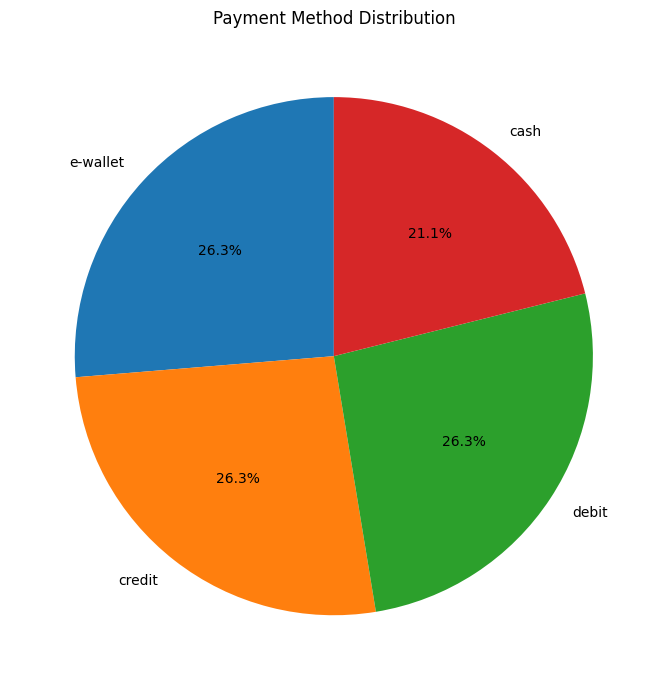

In [33]:
labels = payment_distribution["payment_method"].to_list()
values = payment_distribution["transaction_count"].to_list()

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()